# Quantum Computing and Art: Hands-on Session

This notebook is a dissident of a previous Quantum Computing Summer School for physics students, linked here [Summer-school-July-2025](https://github.com/ariannacrippa/Summer-school-July-2025), ministrated by Dr. Arianna Crippa and Dr. Karl Jansen.
It has now been adapted to the context of a lecture on Quantum Computing for Artists, part of a course at UdK ministrated by Adrian Schwarzer, Alide Di Tucci, Paulo Itaborai and Karl Jansen.

This notebook explores the intersection of quantum computing and visual art by simulating the time evolution of a quantum Ising model and mapping its dynamics onto an image. Using Qiskit and IBM Quantum backends, we construct and simulate quantum circuits, extract measurement data, and use this data to manipulate and reconstruct a famous artwork. The workflow demonstrates how quantum information can be visualized creatively, providing both a technical and artistic perspective on quantum simulation.

> **Important:**  
>To run this notebook, you need a Python environment  with Qiskit and its dependencies installed. You can use a virtual environment:
> ```bash
>python3 -m venv <env_name>
>source <env_name>/bin/activate
> ```
have Qiskit installed. See [Qiskit Installation](https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit) .  
> Install it using:  
>  
> ```bash
> pip install qiskit
> ```
>
> If you intend to use visualization functionality or Jupyter notebooks, it is recommended to install Qiskit with the extra visualization support ('qiskit[visualization]').

>```bash
>pip install qiskit[visualization]
>```

>Then we will also need qiskit-aer, thus:
> ```bash
> pip install qiskit-aer
> ```

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import qiskit
from qiskit import *
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_bloch_vector,plot_bloch_multivector
from qiskit.primitives import BackendEstimatorV2 as Estimator
from scipy.sparse.linalg import eigsh

#For image display
import PIL
from PIL import Image
from io import BytesIO
from IPython.display import display

PIL.Image.MAX_IMAGE_PIXELS = 683802624 # Necessary since some reference images were very large

if int(qiskit.__version__.split('.')[0]) >= 2:
    print(f"Qiskit version is {qiskit.__version__} (>=2)")
else:
    print(f"Qiskit version is {qiskit.__version__} (<2)")

Qiskit version is 1.2.0 (<2)


Test the import above. You should not get errors and qiskit version >=2: Qiskit version is 2.1.0 (>=2)

## Introduction to Quantum circuits

### Single qubit circuits

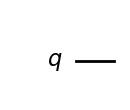

In [2]:
qc=QuantumCircuit(1)
qc.draw('mpl')

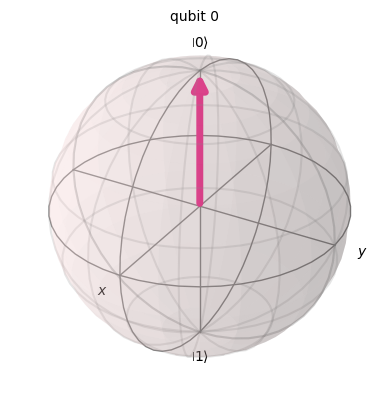

In [3]:
plot_bloch_multivector(Statevector.from_instruction(qc))

#### Apply quantum gates

The $X$ gate, also known as the Pauli-X or quantum NOT gate, flips the state of a qubit from $\lvert 0 \rangle$ to $\lvert 1 \rangle$ and vice versa. Its matrix representation is:

$$
X = \begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$

Applying the $X$ gate to a qubit in state $\lvert 0 \rangle$ results in $\lvert 1 \rangle$, and applying it to $\lvert 1 \rangle$ results in $\lvert 0 \rangle$. This gate is fundamental for creating superposition and entanglement in quantum circuits.

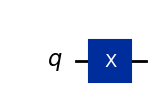

In [4]:
qc=QuantumCircuit(1)
qc.x(0)

qc.draw('mpl')

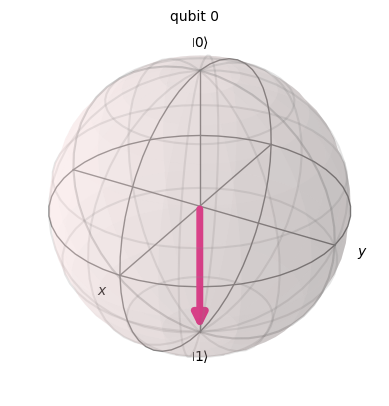

In [5]:
plot_bloch_multivector(Statevector.from_instruction(qc))

The $R_y$ gate is a single-qubit rotation gate that rotates the state of a qubit around the $y$-axis of the Bloch sphere by a given angle $\theta$. Its matrix representation is:

$$
R_y(\theta) = \begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Applying $R_y(\theta)$ to a qubit changes its amplitudes, allowing for the creation of superposition states. This gate is commonly used in quantum algorithms for state preparation and variational circuits.

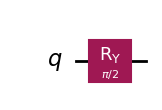

In [6]:
qc=QuantumCircuit(1)
qc.ry(np.pi/2, 0)
qc.draw('mpl')

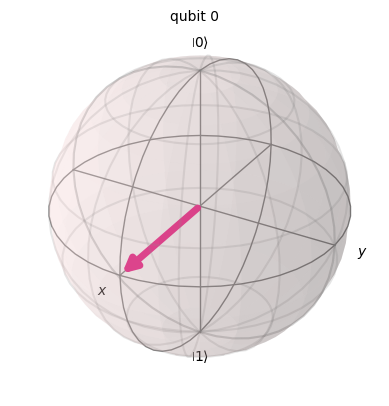

In [7]:
plot_bloch_multivector(Statevector.from_instruction(qc))

### Multiple qubits circuits

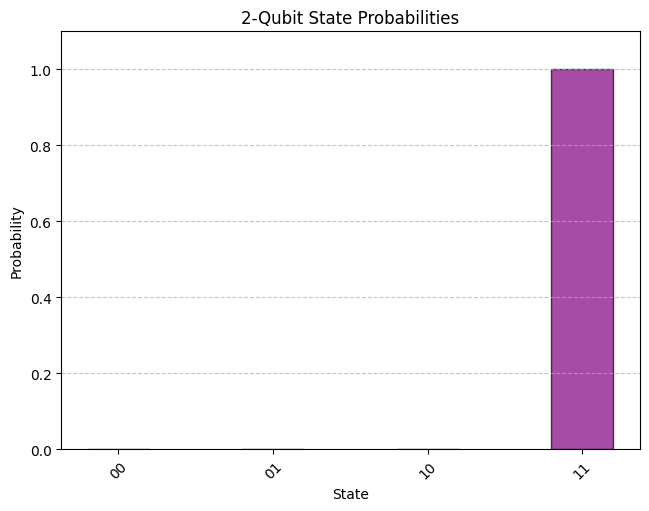

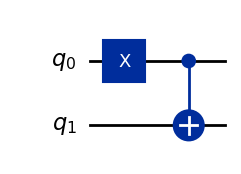

In [8]:
# Create a 2-qubit quantum circuit
qc2 = QuantumCircuit(2)
qc2.x(0)  # Apply X gate to qubit 0 to set it to |1>
qc2.cx(0, 1)  # Apply CNOT with qubit 0 as control and qubit 1 as target

# Simulate the circuit and get the statevector
state = Statevector.from_instruction(qc2)
probs = state.probabilities_dict()

# Plot the probabilities
plt.bar(['00', '01', '10', '11'], [probs.get('00', 0), probs.get('01', 0), probs.get('10', 0), probs.get('11', 0)],
    color='purple', alpha=0.7, edgecolor='black', width=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.1)
plt.xlabel('State')
plt.ylabel('Probability')
plt.title('2-Qubit State Probabilities')
plt.show()


qc2.draw('mpl')

#### Bell state
The Bell state is a maximally entangled quantum state of two qubits. (Hint: use the Hadamard gate) The resulting state is:

$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)
$$

This state exhibits perfect quantum correlations: measuring one qubit instantly determines the outcome of the other, regardless of the distance between them. Bell states are fundamental resources in quantum information, underpinning protocols such as quantum teleportation.

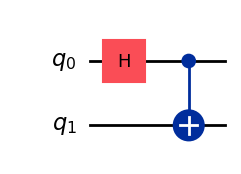

In [9]:
# Create a 2-qubit quantum circuit for the Bell state
bell_circuit = QuantumCircuit(2)

bell_circuit.h(0)  # Apply Hadamard gate to qubit 0
bell_circuit.cx(0, 1)  # Apply CNOT gate with qubit 0 as control and qubit 1 as target


bell_circuit.draw('mpl')

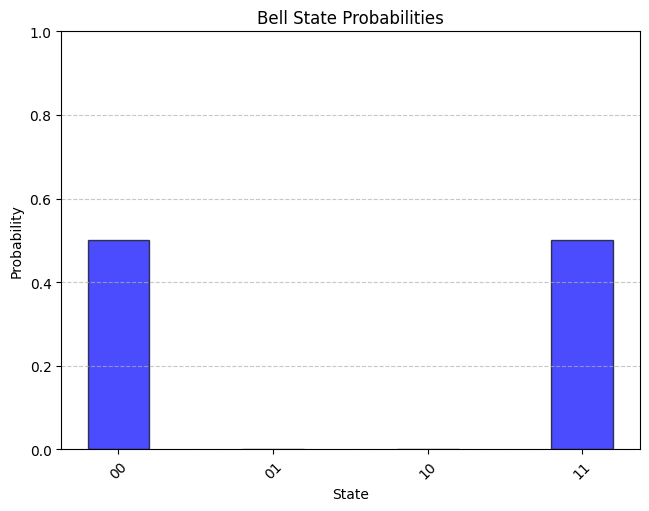

In [10]:
# Simulate the circuit and get the statevector
state = Statevector.from_instruction(bell_circuit)
probs = state.probabilities_dict()

# Plot the probabilities
plt.bar(['00', '01', '10', '11'],
         [probs.get('00', 0), probs.get('01', 0), probs.get('10', 0), probs.get('11', 0)],
         color='blue', alpha=0.7, edgecolor='black', width=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1)
plt.xlabel('State')
plt.ylabel('Probability')
plt.title('Bell State Probabilities')
plt.show()


### Ising model: Hamiltonian spectrum

The Ising Hamiltonian with periodic boundary conditions for $ N $ qubits is:

$$
H = \sum_{j=1}^{N} J_j Z_j Z_{j+1} + \sum_{j=1}^{N} h_j^z Z_j + \sum_{j=1}^{N} h_j^x X_j
$$

where:
- $ Z_j $ and $ X_j $ are the Pauli-Z and Pauli-X operators on qubit $ j $,
- $ J_j $ is the coupling between neighboring qubits,
- $ h_j^z $ and $ h_j^x $ are the longitudinal and transverse field strengths,
- $ Z_{N+1} \equiv Z_1 $ (periodic boundary: the last qubit couples to the first).

In [11]:
# INPUT PARAMS
n_qubits = 6   ### number of qubits


# Coefficients in Ising model
J_list =[-0.5]*n_qubits   # For Z_n Z_{n+1}
hz_list =[0.1]*n_qubits   # For Z_n
hx_list =[1.0]*n_qubits   # For X_n

In [12]:
# Build the Ising Hamiltonian as a SparsePauliOp
paulis = []
coeffs = []

# ZZ terms with periodic boundary conditions
for j in range(n_qubits):
    z_str = ['I'] * n_qubits
    z_str[j] = 'Z'
    z_str[(j + 1) % n_qubits] = 'Z'
    paulis.append(''.join(z_str))
    coeffs.append(J_list[j])

# Z terms
for j in range(n_qubits):
    z_str = ['I'] * n_qubits
    z_str[j] = 'Z'
    paulis.append(''.join(z_str))
    coeffs.append(hz_list[j])

# X terms
for j in range(n_qubits):
    x_str = ['I'] * n_qubits
    x_str[j] = 'X'
    paulis.append(''.join(x_str))
    coeffs.append(hx_list[j])

H = SparsePauliOp(paulis, coeffs=coeffs)
print(H)

SparsePauliOp(['ZZIIII', 'IZZIII', 'IIZZII', 'IIIZZI', 'IIIIZZ', 'ZIIIIZ', 'ZIIIII', 'IZIIII', 'IIZIII', 'IIIZII', 'IIIIZI', 'IIIIIZ', 'XIIIII', 'IXIIII', 'IIXIII', 'IIIXII', 'IIIIXI', 'IIIIIX'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  0.1+0.j,
  0.1+0.j,  0.1+0.j,  0.1+0.j,  0.1+0.j,  0.1+0.j,  1. +0.j,  1. +0.j,
  1. +0.j,  1. +0.j,  1. +0.j,  1. +0.j])


In [13]:
#TODO: Compute the lowest 4 eigenvalues of the Ising Hamiltonian H using scipy.sparse.linalg.eigsh. Call them "eigvals" such that we can print them out.
# H is a SparsePauliOp; use its to_matrix() method to get the matrix representation

H_matrix = H.to_matrix()
eigvals, eigvecs = eigsh(H_matrix, k=4, which='SA')  # 'SA' = smallest algebraic

print("Lowest 4 eigenvalues of H:", np.sort(eigvals))

Lowest 4 eigenvalues of H: [-6.48852029 -5.35355037 -4.67022641 -4.67022641]


In [14]:
# Check if the computed eigenvalues match the expected lowest 4 eigenvalues
expected_eigvals = np.array([-6.48852029, -5.35355037, -4.67022641, -4.67022641])
computed_eigvals = np.sort(eigvals)

if np.allclose(computed_eigvals, expected_eigvals, atol=1e-6):
    print("Eigenvalues match the expected values.")
else:
    print("Eigenvalues do NOT match the expected values.")
    print("Computed:", computed_eigvals)
    print("Expected:", expected_eigvals)

Eigenvalues match the expected values.


### Ising model: time evolution

The Trotter-Suzuki decomposition is a method to approximate the exponential of a sum of non-commuting operators. For a Hamiltonian $H = \sum_j H_j $, the time evolution operator is:

$$
U(t) = e^{-i t H} = e^{-i t \sum_j H_j}
$$

The Trotter approximation is:

$$
e^{-i t \sum_j H_j} \approx \left( \prod_j e^{-i \frac{t}{n} H_j} \right)^n
$$

where $n $ is the number of Trotter steps.

In [ ]:
def time_evolution_Ising(n_qubits:int, J_list:list, hz_list:list, hx_list:list, dt:float) -> QuantumCircuit:
    """Time evolution circuit for the Ising model with periodic boundary conditions: H = sum J_n * Z_n Z_{n+1} + sum h_n * Z_n + sum h_n * X_n
    Args:
        n_qubits: number of qubits
        J_list: interacting couplings for each nearest neighbor
        hz_list: interacting couplings for Z_n for each qubit
        hx_list: interacting couplings for X_n for each qubit
        dt: time step
    Returns:
        circ_dt: QuantumCircuit of the time evolution
    """

    print(f'number of qubits: {n_qubits}')
    q = QuantumRegister(n_qubits)
    circ_dt = QuantumCircuit(q)


    ##  exp(-it * J[n] * Z_n Z_{n+1})
    for n in range(n_qubits):
        circ_dt.rzz(2*dt*J_list[n], q[n], q[(n+1)%n_qubits])

    circ_dt.barrier()

    ##  exp(-it * hx[n] * X_n) exp(-it * hz[n] * Z_n)
    for n in range(n_qubits):
        circ_dt.rz(2*dt*hz_list[n], q[n])
        circ_dt.rx(2*dt*hx_list[n], q[n])



    return circ_dt

number of qubits: 6


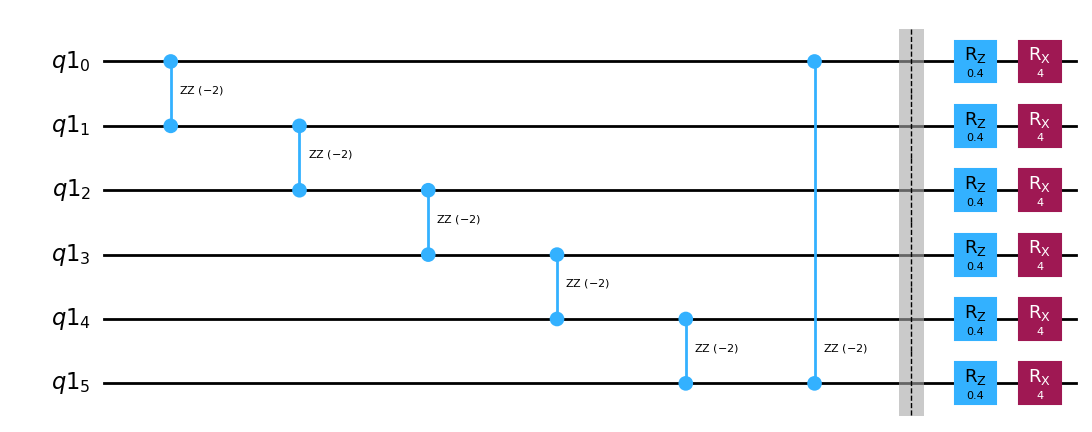

In [16]:
# INPUT PARAMS
dt = 2   ### time step
nsteps=10
T =dt*nsteps
#Define array to save results
tk_list = np.zeros((round(T/dt), n_qubits))


circ = QuantumCircuit(n_qubits)
circ_dt = time_evolution_Ising(n_qubits, J_list, hz_list, hx_list, dt)

#Define operators for each qubit, which will be used to measure the expectation values and set order of tiles
op_list = []
for n in range(n_qubits):
    op_list.append(SparsePauliOp('I'*(n_qubits-n-1) + 'Z' + 'I'*n))


circ_dt.draw('mpl')

### Let's run the code!

We need to select on which backend we will run our quantum circuit.  
Today we will use a **Simulator**

Note that there is no quantum effects in this case, thus, to get more interesting results, we simply reduce the 'default_precision'

In [17]:
backend = AerSimulator()

#Import estimator
estimator = Estimator(backend=backend, options = {"default_precision": 100})
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

We now run the actual time evolution

In [18]:
for step in range(round(T/dt)):
    print('step: ', step)

    isa_circuit = pm.run(circ)
    isa_observables = []
    for op in op_list:
        isa_observables.append(op.apply_layout(isa_circuit.layout))

    job = estimator.run([(isa_circuit, isa_observables)])
    result = job.result()
    for n in range(n_qubits):
        op_exp =result[0].data.evs[n]
        k_tn = (1-op_exp)/2
        tk_list[step, n] =  n + k_tn*10
    circ = circ.compose(circ_dt)


    flat_sorted_indices = np.argsort(tk_list[step,:], axis=None)
    tk_list[step,:] = flat_sorted_indices
    print(f'tk_list: {tk_list[step,:]}')

step:  0
tk_list: [0. 1. 2. 3. 4. 5.]
step:  1
tk_list: [4. 5. 0. 1. 2. 3.]
step:  2
tk_list: [4. 5. 0. 1. 2. 3.]
step:  3
tk_list: [0. 1. 2. 3. 4. 5.]
step:  4
tk_list: [1. 2. 3. 4. 5. 0.]
step:  5
tk_list: [0. 1. 2. 3. 4. 5.]
step:  6
tk_list: [0. 1. 2. 3. 4. 5.]
step:  7
tk_list: [0. 4. 1. 2. 3. 5.]
step:  8
tk_list: [0. 1. 4. 5. 2. 3.]
step:  9
tk_list: [0. 1. 5. 2. 3. 4.]


### Convert into image

In [19]:
# TODO: Load the image
pic = Image.open("vangogh.jpg")

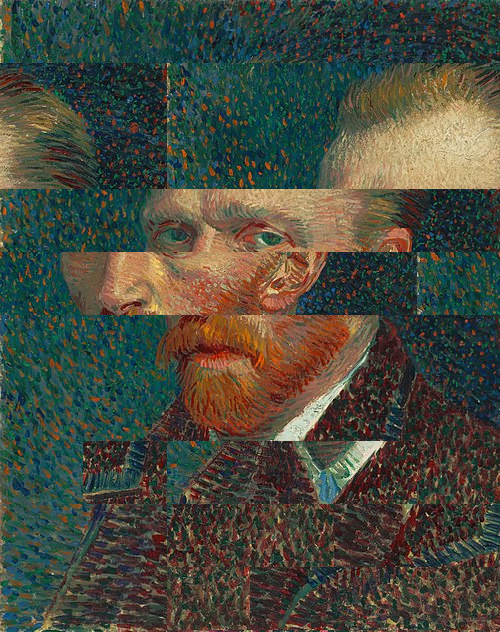

In [20]:
data=[]
for k in tk_list:
    data.append(','.join(['{0:04b}'.format(int(i)) for i in k]))

data_visual=[i.strip().split(',') for i in data]

runs=np.arange(0,nsteps) #this corresponds to the number of lines that we want to generate

finalPic=pic.copy()
hsize = pic.size[0]/n_qubits
vsize = pic.size[1]/nsteps
csize = pic.size[0]/n_qubits


def merge(im1, im2):
    w = im1.size[0] + im2.size[0]
    h = int(vsize)
    im = Image.new("RGBA", (w, h))
    im.paste(im1)
    im.paste(im2, (im1.size[0],0))
    return im

# Create a new image to hold the final result
for k,dat in zip(runs,data_visual):
    linePic = Image.new("RGBA", (0, pic.size[1]))

    for i, result in enumerate(dat):
        box = (int(result,2)*csize, int(pic.size[1]//nsteps*k), int(result,2)*csize+csize, int(pic.size[1]//nsteps*(k+1)))
        linePic = merge(linePic, pic.crop(box))
    finalPic.paste(linePic,(0,int(pic.size[1]//nsteps*k)))

finalPic.save("quantum_art_output.png")
display(finalPic)

## Conclusion

In this hands-on session, we explored the fascinating intersection of quantum computing and art. By simulating the time evolution of the quantum Ising model, we generated quantum data and creatively mapped it onto a visual artwork. This workflow demonstrated how quantum circuits and measurement outcomes can be used not only for scientific analysis but also for artistic expression.

We hope this notebook has provided you with both technical insights into quantum simulation and inspiration for further creative applications of quantum information. Thank you for participating in the summer school, and we encourage you to continue experimenting with quantum circuits and artistic visualizations!


Our webpage: https://qc-paint.quantumland.art/

Notebook creator: Arianna Crippa